## **ResNet18 Model**

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from tqdm import tqdm
from src.data_pipeline import get_dataloaders

In [3]:
class WaterQualityResNet18(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, freeze_backbone=False):
        super().__init__()

        # load pretrained resnet18 model
        if pretrained:
            self.model= models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        else:
            self.model = models.resnet18(weights=None)

        # converting 1000 classes to 3 classes(for clean, muddy and polluted)
        num_features = self.model.fc.in_features
        self.model.fc = nn.Linear(num_features, num_classes)

        # If no need for training backbone
        if freeze_backbone:
            for param in self.resnet.parameters():
                param.requires_grad = False
            for param in self.resnet.fc.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.model(x)

## **Model Training**

In [4]:
print("Torch Version:", torch.__version__)
print("CUDA Version:", torch.version.cuda)
print("Is CUDA Available:", torch.cuda.is_available())

Torch Version: 2.10.0+cu130
CUDA Version: 13.0
Is CUDA Available: True


In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Available Device is {device}')

Available Device is cuda


In [ ]:
def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val_acc = 0.0
    history = {
        'train_acc' : [],
        'train_loss': [],
        'val_acc': [],
        'val_loss': []
    }
    
    for epoch in range(1, epochs+1):
        # training
        model.train()
        running_loss = correct = total = 0

        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch} [Train]'):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            # backprop
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # validation
        model.eval()
        val_loss = correct = total = 0
        with torch.no_grad():
            for imgs, labels in tqdm(test_loader, desc=f'Epoch {epoch} [Val]'):
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(test_loader)
        val_acc = 100 * correct / total

        history['train_acc'].append(train_acc)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)
        
        if(val_acc > best_val_acc):
            from datetime import datetime
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            best_val_acc = val_acc
            torch.save(model.state_dict(),'best_model.pth')
            print('Best model Saved !')

    print(f'Epoch {epoch}: Train Loss {train_loss:.4f}, Train Acc {train_acc:.2f}% | Val Loss {val_loss:.4f}, Val Acc {val_acc:.2f}%')
    return model, history


In [30]:
train_loader, test_loader = get_dataloaders('../data/split_dataset/train','../data/split_dataset/test', batch_size=32)
print(len(train_loader))
print(len(test_loader))

16
5


In [31]:
model = WaterQualityResNet18(num_classes=3, pretrained=True, freeze_backbone=False)
trained_model, history = train_model(model, train_loader, test_loader, epochs=5, lr=1e-3)

Epoch 1 [Val]: 100%|██████████| 5/5 [00:48<00:00,  9.73s/it]


Best model Saved !


Epoch 2 [Val]: 100%|██████████| 5/5 [00:47<00:00,  9.44s/it]


Best model Saved !


Epoch 3 [Val]: 100%|██████████| 5/5 [00:49<00:00,  9.90s/it]


Best model Saved !


Epoch 5 [Val]: 100%|██████████| 5/5 [00:50<00:00, 10.01s/it]

Epoch 5: Train Loss 0.4773, Train Acc 81.10% | Val Loss 3.0889, Val Acc 59.69%


## **Evaluation & Visualization**

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

##### Training Curves

In [35]:
def plot_training_curves(history):
    epochs = range(1, len(history['train_loss'])+1)
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axs[0].plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    axs[0].plot(epochs, history['val_loss'], label='Val Loss', color='red', linewidth=2)
    axs[0].set_title("Loss Curve")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(alpha=0.3)

    # Accuracy
    axs[1].plot(epochs, history['train_acc'], label='Train Acc', color='green', linewidth=2)
    axs[1].plot(epochs, history['val_acc'], label='Val Acc', color='brown', linewidth=2)
    axs[1].set_title("Accuracy Curves")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy (%)")
    axs[1].legend()
    axs[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

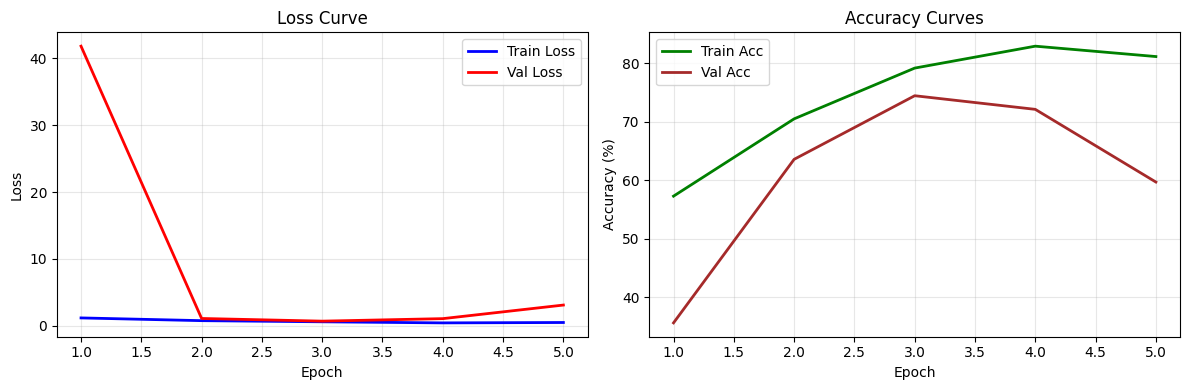

In [36]:
plot_training_curves(history=history)

### Metrics

Test Accuracy: 59.69%
              precision    recall  f1-score   support

       clean       0.53      0.98      0.69        44
       muddy       0.76      0.47      0.58        40
    polluted       0.65      0.33      0.44        45

    accuracy                           0.60       129
   macro avg       0.65      0.60      0.57       129
weighted avg       0.64      0.60      0.57       129



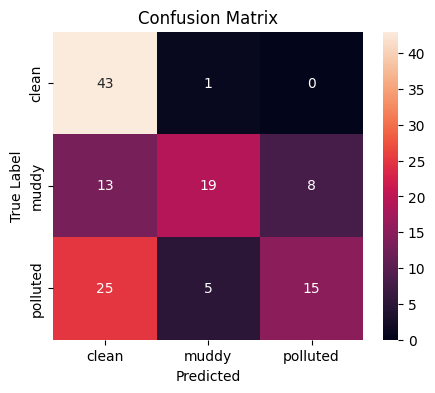

In [37]:
model.eval()
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Classification report
print(classification_report(all_labels, all_preds, target_names=['clean', 'muddy', 'polluted']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# plotting
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['clean','muddy','polluted'], yticklabels=['clean','muddy','polluted'])
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

#### Sample Prediction

In [38]:
from torchvision.transforms import transforms

In [44]:
def visualize_samples(model, image_paths, device, class_names):
    model.eval()
    plt.figure(figsize=(12, 4))
    test_transform = transforms.ToTensor()

    for i, img_path in enumerate(image_paths):
        if i >= 6:
            break

        img = Image.open(img_path).convert("RGB")
        img_tensor = test_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            prob = torch.softmax(output, dim=1)
            conf, pred = torch.max(prob, 1)
            predicted_class = class_names[pred.item()]
            confidence = conf.item() * 100

        plt.subplot(2,3, i + 1)
        plt.imshow(img)
        plt.axis('off')
        colors= {'clean':'green', 'muddy':'orange', 'polluted':'red'}
        plt.title(f"{predicted_class}\n{confidence:.1f}%", color=colors[predicted_class])

    plt.tight_layout()
    plt.show()

In [45]:
class_names = ['clean', 'muddy', 'polluted']
image_paths = ['../data/split_dataset/test/muddy/muddy17.jpg','../data/split_dataset/test/clean/2.jpg','../data/water_dataset/muddy/muddy18.jpg']

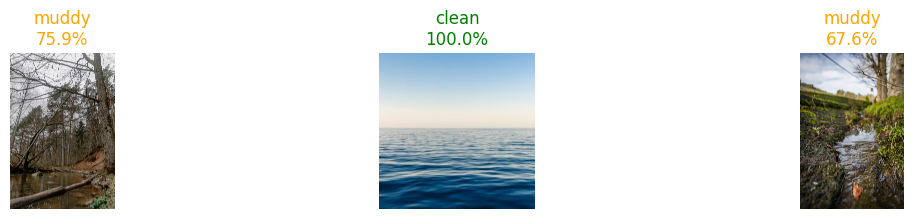

In [46]:
visualize_samples(trained_model, image_paths, device, class_names)